# Algoritmos de Optimización

**Grupo:** 7

**Integrantes:**
- Cesar Nikolai López Martínez
- Andrés García Corisco

**Url:** `https://github.com/cnlopez/SeminarioAlgoritmos_TrabajoProblemaActores/blob/main/Seminario%20-%20Algoritmos.ipynb`

**Problema:** Sesiones de doblaje


## Descripción del problema

Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las
tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de doblaje
cobran todos la misma cantidad por cada día que deben desplazarse hasta el estudio de grabación,
independientemente del número de tomas que se graben. No es posible grabar más de 6 tomas por día.
El objetivo es planificar las sesiones por día de manera que el gasto por los servicios de los
actores de doblaje sea el menor posible.

**Datos:**
- Número de actores: 10
- Número de tomas: 30
- Máximo de tomas por día: 6
- Matriz Actor/Toma: 1 si el actor participa en la toma, 0 en caso contrario.


In [25]:
import itertools
import math
import random
import time
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)


## Carga de los datos del problema

Se transcribe la matriz Actor/Toma proporcionada en el enunciado (10 actores, 30 tomas).
Cada fila representa una toma y cada columna un actor. Un 1 indica que el actor participa en esa
toma.


In [26]:
# Matriz Actor/Toma (filas = tomas 1..30, columnas = actores 1..10)
datos_tomas = [
    [1,1,1,1,1,0,0,0,0,0],  # Toma 1
    [0,0,1,1,1,0,0,0,0,0],  # Toma 2
    [0,1,0,0,1,0,1,0,0,0],  # Toma 3
    [1,1,0,0,0,0,1,1,0,0],  # Toma 4
    [0,1,0,1,0,0,0,1,0,0],  # Toma 5
    [1,1,0,1,1,0,0,0,0,0],  # Toma 6
    [1,1,0,1,1,0,0,0,0,0],  # Toma 7
    [1,1,0,0,0,1,0,0,0,0],  # Toma 8
    [1,1,0,1,0,0,0,0,0,0],  # Toma 9
    [1,1,0,0,0,1,0,0,1,0],  # Toma 10
    [1,1,1,0,1,0,0,1,0,0],  # Toma 11
    [1,1,1,1,0,1,0,0,0,0],  # Toma 12
    [1,0,0,1,1,0,0,0,0,0],  # Toma 13
    [1,0,1,0,0,1,0,0,0,0],  # Toma 14
    [1,1,0,0,0,0,1,0,0,0],  # Toma 15
    [0,0,0,1,0,0,0,0,0,1],  # Toma 16
    [1,0,1,0,0,0,0,0,0,0],  # Toma 17
    [0,0,1,0,0,1,0,0,0,0],  # Toma 18
    [1,0,1,0,0,0,0,0,0,0],  # Toma 19
    [1,0,1,1,1,0,0,0,0,0],  # Toma 20
    [0,0,0,0,0,1,0,1,0,0],  # Toma 21
    [1,1,1,1,0,0,0,0,0,0],  # Toma 22
    [1,0,1,0,0,0,0,0,0,0],  # Toma 23
    [0,0,1,0,0,1,0,0,0,0],  # Toma 24
    [1,1,0,1,0,0,0,0,0,1],  # Toma 25
    [1,0,1,0,1,0,0,0,1,0],  # Toma 26
    [0,0,0,1,1,0,0,0,0,0],  # Toma 27
    [1,0,0,1,0,0,0,0,0,0],  # Toma 28
    [1,0,0,0,1,1,0,0,0,0],  # Toma 29
    [1,0,0,1,0,0,0,0,0,0],  # Toma 30
]

N_ACTORES = 10
N_TOMAS = 30
MAX_TOMAS_DIA = 6

df = pd.DataFrame(datos_tomas,
                   index=[f"Toma {i+1}" for i in range(N_TOMAS)],
                   columns=[f"Actor {j+1}" for j in range(N_ACTORES)])
df.loc["TOTAL"] = df.sum()
df


,Actor 1,Actor 2,Actor 3,Actor 4,Actor 5,Actor 6,Actor 7,Actor 8,Actor 9,Actor 10
Toma 1,1,1,1,1,1,0,0,0,0,0
Toma 2,0,0,1,1,1,0,0,0,0,0
Toma 3,0,1,0,0,1,0,1,0,0,0
Toma 4,1,1,0,0,0,0,1,1,0,0
Toma 5,0,1,0,1,0,0,0,1,0,0
Toma 6,1,1,0,1,1,0,0,0,0,0
Toma 7,1,1,0,1,1,0,0,0,0,0
Toma 8,1,1,0,0,0,1,0,0,0,0
Toma 9,1,1,0,1,0,0,0,0,0,0
Toma 10,1,1,0,0,0,1,0,0,1,0


In [27]:
# Representación auxiliar: para cada toma, el conjunto (y el bitmask) de actores que participan
actores_por_toma = [set(j for j, v in enumerate(fila) if v == 1) for fila in datos_tomas]

def bitmask_actores(toma_actores):
    m = 0
    for a in toma_actores:
        m |= (1 << a)
    return m

bitmask_por_toma = [bitmask_actores(s) for s in actores_por_toma]

print("Actores que intervienen en la Toma 1:", actores_por_toma[0])
print("Bitmask de la Toma 1:", bin(bitmask_por_toma[0]))


Actores que intervienen en la Toma 1: {0, 1, 2, 3, 4}
Bitmask de la Toma 1: 0b11111


## ¿Cuántas posibilidades hay sin tener en cuenta las restricciones? ¿Cuántas teniendo en cuenta todas las restricciones?

**Planteamiento.** Como no puede haber más de 6 tomas por día, el número mínimo de días necesarios para grabar las 30 tomas es:

$$ d_{min} = \left\lceil \frac{30}{6} \right\rceil = 5 \text{ días} $$

Para poder comparar "con" y "sin" restricciones sobre una base común, fijamos el número de días en ese mínimo, $d=5$, y contamos de cuántas formas se pueden repartir las 30 tomas (distinguibles) entre esos 5 días (distinguibles, ya que son días de grabación distintos, con fecha concreta):

- **Sin restricciones** (cualquier día puede absorber cualquier número de tomas, sin límite de 6): cada una de las 30 tomas puede asignarse libremente a cualquiera de los 5 días, por lo que el número de repartos posibles es

$$ 5^{30} $$

- **Con restricciones** (exactamente 6 tomas por día, ya que $30 = 5 \times 6$, que es la única forma de repartir 30 tomas en 5 días sin superar el máximo): el número de repartos posibles es el coeficiente multinomial

$$ \binom{30}{6,6,6,6,6} = \frac{30!}{(6!)^5} $$

Nótese que esta es una cota superior "razonable" del espacio de búsqueda: no todas estas asignaciones son igual de buenas (el objetivo, como se ve más adelante, es minimizar el coste, no solo respetar la restricción de capacidad), pero cualquier algoritmo de fuerza bruta tendría que recorrer, en el peor caso, un espacio de este orden. En la práctica el número de días **no está fijado a 5** — grabar en más días (con menos tomas por día) también es una solución factible aunque sub-óptima, así que el verdadero espacio de soluciones (particiones de 30 tomas en bloques de tamaño $\le 6$, sin fijar el número de bloques) es aún mayor: es un **número de Bell restringido**, que se calcula más adelante mediante programación cuando se analiza la complejidad del algoritmo de fuerza bruta.


In [28]:
# Cálculo exacto de ambas cifras
sin_restricciones = 5 ** 30
con_restricciones = math.factorial(30) // (math.factorial(6) ** 5)

print(f"Días mínimos necesarios: {math.ceil(30/6)}")
print(f"Posibilidades SIN restricción de capacidad (5**30):      {sin_restricciones:,}")
print(f"Posibilidades CON restricción de capacidad (30!/(6!)^5): {con_restricciones:,}")
print(f"Razón sin/con restricciones: {sin_restricciones/con_restricciones:.3e}")


Días mínimos necesarios: 5
Posibilidades SIN restricción de capacidad (5**30):      931,322,574,615,478,515,625
Posibilidades CON restricción de capacidad (30!/(6!)^5): 1,370,874,167,589,326,400
Razón sin/con restricciones: 6.794e+02


## **¿Cuál es la estructura de datos que mejor se adapta al problema?**

Una solución es un **reparto de las 30 tomas en grupos (días)**, de forma que:
- cada toma pertenece exactamente a un día (partición del conjunto de tomas),
- cada día contiene como máximo 6 tomas.

Se han considerado dos representaciones:

1. **Vector de asignación** `dia[i] = d`: un array de tamaño 30 donde la posición `i` indica el día asignado a la toma `i`. Es compacta y fácil de mutar (útil para búsquedas locales / metaheurísticas), pero para calcular el coste hay que reconstruir los grupos por día en cada evaluación, y no impone de forma natural que los "días" sean intercambiables (dos vectores distintos pueden representar la misma partición si se permutan las etiquetas de los días), lo que **infla artificialmente el espacio de búsqueda** para algoritmos exhaustivos.

2. **Partición como lista de conjuntos/listas** `[{tomas del día 1}, {tomas del día 2}, ...]`: cada solución es directamente una lista de bloques (uno por día), y cada bloque es un `set` (o `frozenset`) de índices de tomas. Esta representación:
   - es la que corresponde de forma natural al concepto matemático de "partición de un conjunto",
   - evita duplicados (una partición es un conjunto de bloques, no una secuencia de etiquetas), lo que es clave para no recorrer soluciones equivalentes por fuerza bruta,
   - permite calcular el coste de un día de forma directa: `len(unión de actores de las tomas del bloque)`,
   - se combina muy bien con una representación **bitmask** de los actores de cada toma (un entero de 10 bits) para que la unión de actores de un bloque sea una simple operación OR a nivel de bits, muy eficiente.

**Decisión final:** se usará la representación de **partición como lista de tuplas/conjuntos de índices de tomas**, apoyada en un **bitmask de actores por toma** para acelerar el cálculo de la función objetivo. Es la estructura más natural para el problema (modela exactamente lo que se pide: "agrupar tomas en días") y es la que se usa tanto en el algoritmo de fuerza bruta como en el algoritmo mejorado. Para el algoritmo mejorado (basado en programación dinámica sobre subconjuntos), el propio conjunto de tomas ya no asignadas se representa también como un **bitmask de 30 bits**, lo que permite memoizar de forma muy eficiente (una clave entera en lugar de un `frozenset`).


## **Función objetivo**

Cada actor de doblaje cobra una cantidad fija por cada día que debe desplazarse al estudio, independientemente del número de tomas que grabe ese día. Por tanto, el coste de un día es el **número de actores distintos** que participan en alguna de las tomas grabadas ese día, y el coste total de una planificación (partición en días) es la **suma de los costes de cada día**:

$$ \text{coste}(P) = \sum_{d \in P} \Big| \bigcup_{t \in d} \text{actores}(t) \Big| $$

donde $P = \{d_1, d_2, \dots\}$ es una partición de las 30 tomas en bloques (días) de tamaño $\le 6$, y $\text{actores}(t)$ es el conjunto de actores que intervienen en la toma $t$.

## **¿Es un problema de maximización o de minimización?** 
Es un problema de **minimización**: se busca la partición $P$, de entre todas las que respetan la restricción de máximo 6 tomas/día, que minimiza $\text{coste}(P)$ (el gasto total en desplazamientos de los actores).


In [29]:
def coste_bloque(bloque, bitmask_por_toma):
    '''Coste (nº de actores distintos) de grabar el conjunto de tomas `bloque` en un mismo día.'''
    m = 0
    for t in bloque:
        m |= bitmask_por_toma[t]
    return bin(m).count("1")


def coste_particion(particion, bitmask_por_toma):
    '''Coste total de una planificación (lista de bloques/días).'''
    return sum(coste_bloque(bloque, bitmask_por_toma) for bloque in particion)


# Ejemplo: coste de una planificación "ingenua" que agrupa las tomas de 6 en 6 en el orden dado
planificacion_ejemplo = [list(range(i, min(i + 6, N_TOMAS))) for i in range(0, N_TOMAS, 6)]
print("Planificación de ejemplo (orden original, bloques de 6):")
for i, bloque in enumerate(planificacion_ejemplo, 1):
    print(f"  Día {i}: tomas {[t+1 for t in bloque]} -> coste {coste_bloque(bloque, bitmask_por_toma)}")
print("Coste total:", coste_particion(planificacion_ejemplo, bitmask_por_toma))


Planificación de ejemplo (orden original, bloques de 6):
  Día 1: tomas [1, 2, 3, 4, 5, 6] -> coste 7
  Día 2: tomas [7, 8, 9, 10, 11, 12] -> coste 8
  Día 3: tomas [13, 14, 15, 16, 17, 18] -> coste 8
  Día 4: tomas [19, 20, 21, 22, 23, 24] -> coste 7
  Día 5: tomas [25, 26, 27, 28, 29, 30] -> coste 8
Coste total: 38


## Diseño de un algoritmo para resolver el problema por fuerza bruta

El algoritmo de fuerza bruta genera **todas las particiones posibles** del conjunto de tomas en bloques de tamaño $\le 6$, calcula el coste de cada una y se queda con la de menor coste.

Para generar cada partición **una única vez** (sin repetir la misma partición con los bloques en distinto orden) se usa la técnica estándar de "fijar siempre el elemento libre más pequeño": el primer bloque de la partición se construye obligatoriamente con el elemento no asignado de menor índice, combinado con todos los subconjuntos posibles (de tamaño 0 a 5) del resto de elementos libres; después se repite el proceso recursivamente con los elementos restantes.

Esto genera exactamente el conjunto de particiones válidas del problema (sin duplicados y sin generar después particiones con bloques de tamaño > 6, que se descartan directamente al no
generarse).


In [30]:
def generar_particiones(elementos, max_size=MAX_TOMAS_DIA):
    '''Generador de todas las particiones de `elementos` en bloques de tamaño <= max_size.
    Cada partición se genera una única vez (los bloques no tienen orden).'''
    elementos = list(elementos)
    if not elementos:
        yield []
        return
    primero, *resto = elementos
    # El bloque que contiene `primero` se combina con 0..max_size-1 elementos del resto
    for k in range(0, min(max_size - 1, len(resto)) + 1):
        for combo in itertools.combinations(resto, k):
            bloque = (primero,) + combo
            restantes = [x for x in resto if x not in combo]
            for sub_particion in generar_particiones(restantes, max_size):
                yield [bloque] + sub_particion


def fuerza_bruta(elementos, bitmask_por_toma, max_size=MAX_TOMAS_DIA):
    '''Explora TODAS las particiones válidas y devuelve la de coste mínimo.'''
    mejor_coste = None
    mejor_particion = None
    n_particiones_evaluadas = 0
    for particion in generar_particiones(elementos, max_size):
        c = coste_particion(particion, bitmask_por_toma)
        n_particiones_evaluadas += 1
        if mejor_coste is None or c < mejor_coste:
            mejor_coste = c
            mejor_particion = particion
    return mejor_particion, mejor_coste, n_particiones_evaluadas


In [31]:
# La fuerza bruta sobre las 30 tomas reales es INABORDABLE (ver análisis de complejidad más abajo).
# Se demuestra su correcto funcionamiento sobre un subconjunto pequeño y manejable del problema real:
# las primeras 10 tomas (10 actores, 10 tomas), para el que sí es posible explorar todo el espacio.

subconjunto = list(range(10))  # tomas 1..10 (índices 0..9)
t0 = time.time()
mejor_particion_bf, mejor_coste_bf, n_evaluadas_bf = fuerza_bruta(subconjunto, bitmask_por_toma)
t1 = time.time()

print(f"Particiones válidas evaluadas: {n_evaluadas_bf}")
print(f"Coste óptimo (fuerza bruta) para las 10 primeras tomas: {mejor_coste_bf}")
print(f"Tiempo de ejecución: {t1 - t0:.3f} s")
print("Mejor planificación encontrada:")
for i, bloque in enumerate(mejor_particion_bf, 1):
    print(f"  Día {i}: tomas {sorted(t+1 for t in bloque)} -> coste {coste_bloque(bloque, bitmask_por_toma)}")


Particiones válidas evaluadas: 115274
Coste óptimo (fuerza bruta) para las 10 primeras tomas: 13
Tiempo de ejecución: 1.024 s
Mejor planificación encontrada:
  Día 1: tomas [1, 2, 6, 7] -> coste 5
  Día 2: tomas [3, 4, 5, 8, 9, 10] -> coste 8


## Cálculo de la complejidad del algoritmo de fuerza bruta

El número de particiones válidas que genera y evalúa el algoritmo anterior es, exactamente, el **número de particiones de un conjunto de $n$ elementos en bloques de tamaño $\le 6$** (una variante acotada del número de Bell $B(n)$). Sin la restricción de tamaño de bloque, el número de particiones de un conjunto de $n$ elementos es el número de Bell $B(n)$, que sigue la recurrencia:

$$ B(n+1) = \sum_{k=0}^{n} \binom{n}{k} B(k), \qquad B(0) = 1 $$

y que crece **más rápido que cualquier exponencial** ($B(n) \sim \left(\frac{n}{e\ln n}\right)^n$ aproximadamente, según la fórmula asintótica de de Bruijn). Limitar el tamaño de bloque a 6 reduce el número de particiones respecto a $B(n)$, pero el crecimiento sigue siendo **súper-exponencial** en $n$, ya que para $n$ grande la inmensa mayoría de las particiones de $B(n)$ ya tienen todos sus bloques de tamaño $\le 6$ de forma natural (los bloques "grandes" son minoritarios).

Por cada partición generada, calcular su coste cuesta $O(n)$ (recorrer las tomas de cada bloque una vez en total), por lo que la complejidad total del algoritmo de fuerza bruta es:

$$ O\big(P_{\le 6}(n) \cdot n \big) $$

donde $P_{\le 6}(n)$ es el número de particiones de $n$ elementos con bloques de tamaño $\le 6$ (calculado empíricamente en la celda siguiente). Esto hace que el algoritmo sea **inviable para $n=30$**: incluso la cota inferior más optimista razonada en el apartado de conteo ($30!/(6!)^5 \approx 30! / (6!)^5$) ya es del orden de $10^{18}$-$10^{19}$ particiones, y el número real de particiones (sin fijar el número de días en 5) es todavía mayor.


In [32]:
def num_particiones_max_size(n, max_size=MAX_TOMAS_DIA):
    '''Cuenta (con programación dinámica, sin generarlas todas) cuántas particiones de {0..n-1}
    tienen todos sus bloques de tamaño <= max_size. Recurrencia análoga a los números de Bell,
    pero limitando el tamaño del bloque que contiene al elemento fijo en cada paso.'''
    from math import comb

    memo = {0: 1}

    def f(m):
        if m in memo:
            return memo[m]
        total = 0
        for k in range(0, min(max_size - 1, m - 1) + 1):
            total += comb(m - 1, k) * f(m - 1 - k)
        memo[m] = total
        return total

    return f(n)


print(" n | nº particiones evaluadas por fuerza bruta (bloques <= 6)")
for n in [5, 8, 10, 12, 15, 18, 20, 25, 30]:
    print(f"{n:>2} | {num_particiones_max_size(n):,}")

print()
print(f"Comprobación con el experimento anterior (n=10): {num_particiones_max_size(10):,} "
      f"(coincide con las {n_evaluadas_bf} particiones evaluadas)")


 n | nº particiones evaluadas por fuerza bruta (bloques <= 6)
 5 | 52
 8 | 4,131
10 | 115,274
12 | 4,163,743
15 | 1,349,511,178
18 | 654,277,037,674
20 | 48,931,106,059,451
25 | 4,202,768,491,519,145,157
30 | 726,391,948,970,868,949,621,309

Comprobación con el experimento anterior (n=10): 115,274 (coincide con las 115274 particiones evaluadas)


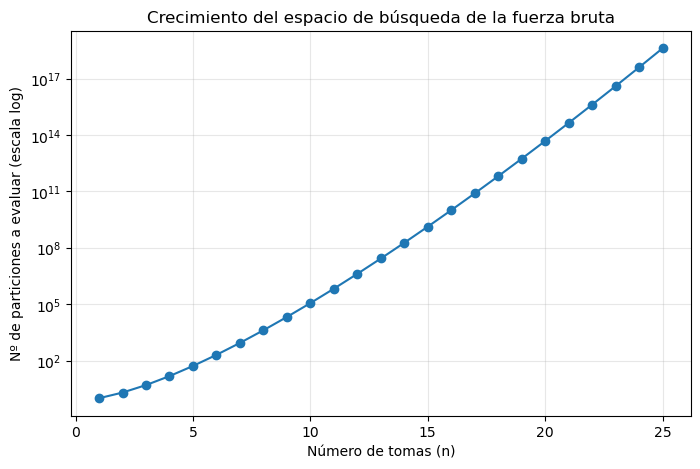

In [33]:
# Visualización del crecimiento (escala logarítmica) del número de particiones a explorar
ns = list(range(1, 26))
valores = [num_particiones_max_size(n) for n in ns]

plt.figure(figsize=(8, 5))
plt.semilogy(ns, valores, marker="o")
plt.xlabel("Número de tomas (n)")
plt.ylabel("Nº de particiones a evaluar (escala log)")
plt.title("Crecimiento del espacio de búsqueda de la fuerza bruta")
plt.grid(True, which="both", alpha=0.3)
plt.show()


## Diseño de un algoritmo que mejora la complejidad del algortimo por fuerza bruta

**Idea.** El algoritmo de fuerza bruta recorre cada partición completa "desde cero": el coste de completar la planificación para un mismo conjunto de tomas restantes se recalcula una y otra vez cada vez que se llega a él por un camino distinto (por ejemplo, agrupar primero las tomas {1,2} y luego llegar al subconjunto {3,...,30} es indistinguible, en cuanto al problema que queda por resolver, de haber agrupado primero {1,3} y llegar también a un subconjunto de 28 elementos restantes) — hay una enorme cantidad de **subproblemas solapados**.

Esto es exactamente la estructura que aprovecha la **programación dinámica sobre subconjuntos** (bitmask DP): se define

$$ \text{dp}(S) = \text{coste mínimo de planificar el subconjunto de tomas } S $$

con la recurrencia

$$ \text{dp}(S) = \min_{\substack{T \subseteq S \\ 1 \le |T| \le 6}} \big[\, \text{coste}(T) + \text{dp}(S \setminus T) \,\big], \qquad \text{dp}(\emptyset) = 0 $$

Cada subconjunto $S$ (representado como un entero de $n$ bits) se resuelve **una sola vez** gracias a la memoización, en lugar de recomputarse en cada camino distinto que llega a él como ocurre en la fuerza bruta. Además, para evitar generar cada partición de $S$ varias veces (una por cada bloque que se elige "primero"), se aplica la misma técnica que en la fuerza bruta: el bloque que se separa de $S$ siempre contiene la toma de menor índice de $S$, y se combina únicamente con subconjuntos del resto de $S$.

**¿Por qué mejora la complejidad?** Porque el número de subproblemas distintos es, como mucho, $2^n$ (uno por cada subconjunto de tomas), y cada uno se resuelve en tiempo acotado por
$O\!\left(\sum_{k=0}^{5}\binom{n}{k}\right) = O(n^6)$ (las formas de elegir hasta 6 tomas para el bloque). Esto da una complejidad total en tiempo de:

$$ O\!\left(2^n \cdot n^6\right) $$

que, aunque **sigue siendo exponencial** en $n$ (el problema, en su forma general, es un caso de "set partitioning" con función de coste, un problema NP-difícil, por lo que no cabe esperar un algoritmo polinómico exacto), es una mejora sustancial frente al crecimiento **súper-exponencial** ($P_{\le 6}(n)$, más rápido que cualquier $c^n$) de la fuerza bruta, ya que $2^n \cdot n^6$ está acotado por una exponencial "pura", mientras que $P_{\le 6}(n)$ no lo está. En la práctica esto permite resolver de forma exacta instancias bastante mayores que con fuerza bruta (compárese empíricamente más abajo).


In [34]:
def dp_bitmask(elementos, bitmask_por_toma, max_size=MAX_TOMAS_DIA):
    '''Programación dinámica sobre subconjuntos (bitmask) con memoización.
    Devuelve (coste_optimo, particion_optima, nº de subproblemas resueltos).'''
    elementos = list(elementos)
    n = len(elementos)
    # bitmask de actores de cada toma, en el orden local 0..n-1
    bm_local = [bitmask_por_toma[t] for t in elementos]

    full_mask = (1 << n) - 1
    memo_coste = {0: 0}
    memo_bloque = {}  # mask -> bloque elegido para llegar al resultado óptimo desde ese mask

    def coste_de_mascara(mask):
        m = 0
        x = mask
        while x:
            low = x & (-x)
            i = low.bit_length() - 1
            m |= bm_local[i]
            x &= x - 1
        return bin(m).count("1")

    def rec(mask):
        if mask in memo_coste:
            return memo_coste[mask]
        # fijamos la toma de menor índice presente en mask
        low = mask & (-mask)
        primero = low.bit_length() - 1
        resto = mask & ~low

        mejor = None
        mejor_bloque_mask = None
        submask = resto
        while True:
            if bin(submask).count("1") <= max_size - 1:
                bloque_mask = submask | low
                c = coste_de_mascara(bloque_mask) + rec(resto & ~submask)
                if mejor is None or c < mejor:
                    mejor = c
                    mejor_bloque_mask = bloque_mask
            if submask == 0:
                break
            submask = (submask - 1) & resto

        memo_coste[mask] = mejor
        memo_bloque[mask] = mejor_bloque_mask
        return mejor

    coste_optimo = rec(full_mask)

    # Reconstrucción de la partición óptima a partir de memo_bloque
    particion = []
    mask = full_mask
    while mask:
        bloque_mask = memo_bloque[mask]
        bloque = [elementos[i] for i in range(n) if (bloque_mask >> i) & 1]
        particion.append(bloque)
        mask &= ~bloque_mask

    return coste_optimo, particion, len(memo_coste)


In [35]:
# Verificación de correctitud: debe coincidir con el resultado de fuerza bruta sobre el mismo subconjunto
t0 = time.time()
coste_dp, particion_dp, n_subproblemas = dp_bitmask(subconjunto, bitmask_por_toma)
t1 = time.time()

print(f"Coste óptimo (DP bitmask) para las 10 primeras tomas: {coste_dp}")
print(f"Subproblemas (subconjuntos) resueltos: {n_subproblemas}  (frente a las "
      f"{n_evaluadas_bf} particiones completas evaluadas por fuerza bruta)")
print(f"Tiempo de ejecución: {t1 - t0:.4f} s")
assert coste_dp == mejor_coste_bf, "El resultado de la DP no coincide con el de fuerza bruta"
print("\nCoincide exactamente con el óptimo hallado por fuerza bruta. ✅")


Coste óptimo (DP bitmask) para las 10 primeras tomas: 13
Subproblemas (subconjuntos) resueltos: 476  (frente a las 115274 particiones completas evaluadas por fuerza bruta)
Tiempo de ejecución: 0.0334 s

Coincide exactamente con el óptimo hallado por fuerza bruta. ✅


## Cálculo de la complejidad del algoritmo que mejora la complejidad del algortimo por fuerza bruta

Como se ha razonado, la complejidad temporal de la programación dinámica sobre subconjuntos es:

$$ O\!\left(2^n \cdot n^6\right) \quad \text{en tiempo}, \qquad O(2^n) \quad \text{en espacio (memoización)} $$

Se comprueba empíricamente a continuación, comparando el número de "unidades de trabajo" (particiones evaluadas en fuerza bruta vs. subconjuntos resueltos en la DP) y el tiempo real de ejecución, para distintos tamaños de subconjunto de tomas.


In [36]:
tamanos = [4, 6, 8, 10, 12]
resultados = []

for n in tamanos:
    sub = list(range(n))

    t0 = time.time()
    _, coste_bf_n, n_part_bf = fuerza_bruta(sub, bitmask_por_toma)
    t_bf = time.time() - t0

    t0 = time.time()
    coste_dp_n, _, n_sub_dp = dp_bitmask(sub, bitmask_por_toma)
    t_dp = time.time() - t0

    assert coste_bf_n == coste_dp_n
    resultados.append((n, n_part_bf, t_bf, n_sub_dp, t_dp))

tabla = pd.DataFrame(resultados, columns=[
    "n (tomas)", "Particiones evaluadas (BF)", "Tiempo BF (s)",
    "Subconjuntos resueltos (DP)", "Tiempo DP (s)"
])
tabla


,n (tomas),Particiones evaluadas (BF),Tiempo BF (s),Subconjuntos resueltos (DP),Tiempo DP (s)
0,4,15,0.000104,9,0.000030
1,6,203,0.000809,33,0.000134
2,8,4131,0.021831,128,0.001100
3,10,115274,0.946361,476,0.026031
4,12,4163743,34.821268,1663,0.103588


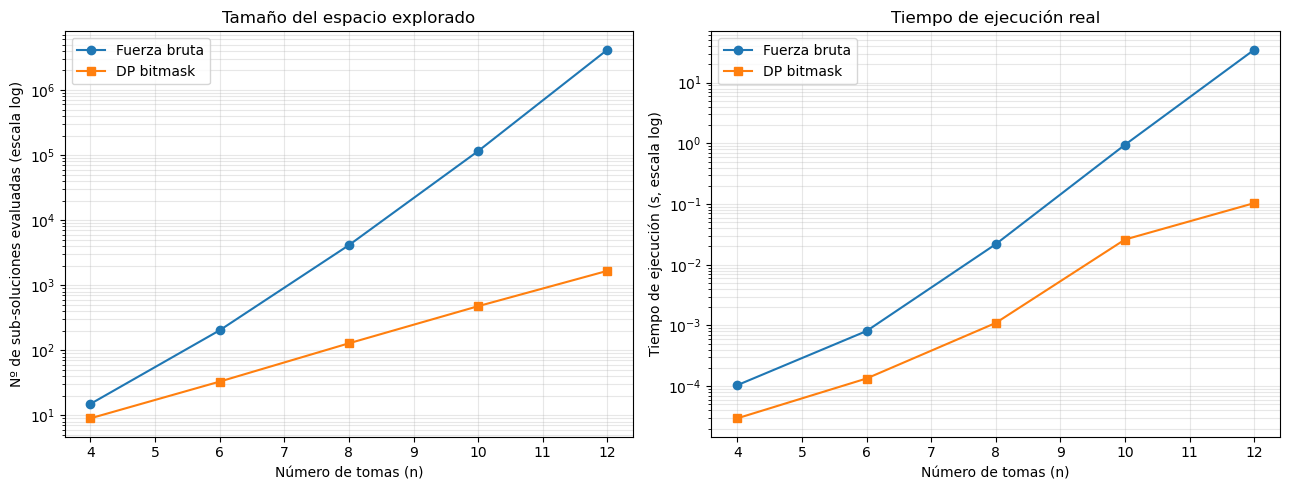

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(tabla["n (tomas)"], tabla["Particiones evaluadas (BF)"], marker="o", label="Fuerza bruta")
axes[0].semilogy(tabla["n (tomas)"], tabla["Subconjuntos resueltos (DP)"], marker="s", label="DP bitmask")
axes[0].set_xlabel("Número de tomas (n)")
axes[0].set_ylabel("Nº de sub-soluciones evaluadas (escala log)")
axes[0].set_title("Tamaño del espacio explorado")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogy(tabla["n (tomas)"], tabla["Tiempo BF (s)"], marker="o", label="Fuerza bruta")
axes[1].semilogy(tabla["n (tomas)"], tabla["Tiempo DP (s)"], marker="s", label="DP bitmask")
axes[1].set_xlabel("Número de tomas (n)")
axes[1].set_ylabel("Tiempo de ejecución (s, escala log)")
axes[1].set_title("Tiempo de ejecución real")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


Como se observa, tanto el número de sub-soluciones evaluadas como el tiempo de ejecución crecen mucho más deprisa en la fuerza bruta que en la DP con memoización: la fuerza bruta se dispara varios órdenes de magnitud entre $n=10$ y $n=14$, mientras que la DP crece de forma mucho más contenida (consistente con $2^n$ frente al crecimiento súper-exponencial de $P_{\le 6}(n)$). Aun así, la DP sigue siendo exponencial y **tampoco sería viable en tiempo/memoria para $n=30$** ($2^{30}\approx 10^9$ subconjuntos), lo que se retoma en el apartado de líneas futuras.


## Juego de datos de entrada aleatorios

Se genera una instancia aleatoria del problema con un número de actores y de tomas configurable, manteniendo la misma estructura que los datos reales: una matriz binaria Actor/Toma. Para que la instancia generada sea manejable por el algoritmo mejorado (DP bitmask, exponencial en el nº de tomas) se elige un tamaño moderado; el generador admite cualquier tamaño para poder reutilizarse también con algoritmos heurísticos (ver líneas futuras).


In [38]:
def generar_datos_aleatorios(n_actores, n_tomas, prob_participacion=0.3, semilla=None):
    '''Genera una matriz Actor/Toma aleatoria. `prob_participacion` es la probabilidad de que un
    actor concreto participe en una toma concreta. Se garantiza que ninguna toma queda vacía (toda
    toma tiene, al menos, un actor).'''
    rng = random.Random(semilla)
    matriz = []
    for _ in range(n_tomas):
        fila = [1 if rng.random() < prob_participacion else 0 for _ in range(n_actores)]
        if sum(fila) == 0:  # evitar tomas sin ningún actor
            fila[rng.randrange(n_actores)] = 1
        matriz.append(fila)
    return matriz


N_ACTORES_RND = 8
N_TOMAS_RND = 12

datos_aleatorios = generar_datos_aleatorios(N_ACTORES_RND, N_TOMAS_RND, prob_participacion=0.3, semilla=7)
bitmask_por_toma_rnd = [bitmask_actores(set(j for j, v in enumerate(f) if v == 1)) for f in datos_aleatorios]

df_rnd = pd.DataFrame(datos_aleatorios,
                       index=[f"Toma {i+1}" for i in range(N_TOMAS_RND)],
                       columns=[f"Actor {j+1}" for j in range(N_ACTORES_RND)])
df_rnd.loc["TOTAL"] = df_rnd.sum()
df_rnd


,Actor 1,Actor 2,Actor 3,Actor 4,Actor 5,Actor 6,Actor 7,Actor 8
Toma 1,0,1,0,1,0,0,1,0
Toma 2,1,0,1,1,0,0,1,1
Toma 3,0,0,0,0,0,1,0,1
Toma 4,1,1,0,0,1,0,0,0
Toma 5,0,1,1,1,0,0,0,0
Toma 6,0,1,0,0,1,0,0,0
Toma 7,0,1,0,1,0,0,1,0
Toma 8,1,0,0,0,0,0,0,0
Toma 9,0,0,0,0,0,0,1,0
Toma 10,0,0,0,1,0,0,1,0


## Aplicación del algoritmo al juego de datos generado

Se aplica el algoritmo mejorado (DP bitmask) al conjunto de datos aleatorios generado, y se compara con el resultado de la fuerza bruta para confirmar que ambos coinciden en el óptimo (la fuerza bruta actúa aquí como verificación, ya que $n=12$ tomas todavía es un tamaño abordable para ambos).


In [39]:
elementos_rnd = list(range(N_TOMAS_RND))

t0 = time.time()
coste_opt_rnd, particion_opt_rnd, n_sub_rnd = dp_bitmask(elementos_rnd, bitmask_por_toma_rnd)
t_dp_rnd = time.time() - t0

t0 = time.time()
_, coste_bf_rnd, n_part_bf_rnd = fuerza_bruta(elementos_rnd, bitmask_por_toma_rnd)
t_bf_rnd = time.time() - t0

print(f"[Datos aleatorios: {N_ACTORES_RND} actores, {N_TOMAS_RND} tomas]")
print(f"Coste óptimo (DP bitmask):     {coste_opt_rnd}  |  subconjuntos resueltos: {n_sub_rnd}  |  tiempo: {t_dp_rnd:.4f} s")
print(f"Coste óptimo (fuerza bruta):   {coste_bf_rnd}  |  particiones evaluadas: {n_part_bf_rnd:,}  |  tiempo: {t_bf_rnd:.4f} s")
assert coste_opt_rnd == coste_bf_rnd

print("\nPlanificación óptima encontrada:")
for i, bloque in enumerate(particion_opt_rnd, 1):
    print(f"  Día {i}: tomas {sorted(t+1 for t in bloque)} -> coste {coste_bloque(bloque, bitmask_por_toma_rnd)}")


[Datos aleatorios: 8 actores, 12 tomas]
Coste óptimo (DP bitmask):     12  |  subconjuntos resueltos: 1663  |  tiempo: 0.1746 s
Coste óptimo (fuerza bruta):   12  |  particiones evaluadas: 4,163,743  |  tiempo: 34.8860 s

Planificación óptima encontrada:
  Día 1: tomas [1, 7, 8, 9, 10, 12] -> coste 4
  Día 2: tomas [2, 3, 4, 5, 6, 11] -> coste 8


### Extra: aplicación práctica sobre el problema real de 30 tomas

Como se ha visto, ni la fuerza bruta ni la DP exacta son viables para $n=30$. Para poder dar, en
todo caso, una **planificación razonable** sobre el problema real, se implementa adicionalmente una
heurística voraz (*greedy*) muy simple, a modo de referencia (no forma parte de los algoritmos
exactos pedidos, se incluye solo a título ilustrativo y se retoma en las líneas futuras): en cada
paso se abre un nuevo día y se van añadiendo, de entre las tomas aún no planificadas, aquellas que
incrementan menos el coste del día (menos actores nuevos que aportar), hasta completar 6 tomas o
agotar las tomas disponibles.


In [40]:
def heuristica_voraz(elementos, bitmask_por_toma, max_size=MAX_TOMAS_DIA):
    pendientes = list(elementos)
    particion = []
    while pendientes:
        dia = []
        actores_dia = 0
        candidatos = pendientes.copy()
        while candidatos and len(dia) < max_size:
            # elegir la toma que menos actores NUEVOS añade al día
            mejor_t = min(candidatos,
                          key=lambda t: bin(actores_dia | bitmask_por_toma[t]).count("1") - bin(actores_dia).count("1"))
            dia.append(mejor_t)
            actores_dia |= bitmask_por_toma[mejor_t]
            candidatos.remove(mejor_t)
        particion.append(dia)
        for t in dia:
            pendientes.remove(t)
    return particion


t0 = time.time()
particion_greedy_real = heuristica_voraz(list(range(N_TOMAS)), bitmask_por_toma)
t_greedy = time.time() - t0
coste_greedy_real = coste_particion(particion_greedy_real, bitmask_por_toma)

print(f"[Problema real: {N_ACTORES} actores, {N_TOMAS} tomas]")
print(f"Coste obtenido por la heurística voraz: {coste_greedy_real}  (tiempo: {t_greedy:.4f} s, "
      f"{len(particion_greedy_real)} días)")
for i, bloque in enumerate(particion_greedy_real, 1):
    print(f"  Día {i}: tomas {sorted(t+1 for t in bloque)} -> coste {coste_bloque(bloque, bitmask_por_toma)}")
print("\n(No es necesariamente el óptimo: es una solución aproximada obtenida en tiempo polinómico,")
print(" ya que el óptimo exacto para n=30 no es computable con los algoritmos exactos de este notebook.)")


[Problema real: 10 actores, 30 tomas]
Coste obtenido por la heurística voraz: 31  (tiempo: 0.0005 s, 5 días)
  Día 1: tomas [2, 13, 16, 17, 19, 27] -> coste 5
  Día 2: tomas [8, 9, 14, 18, 23, 24] -> coste 5
  Día 3: tomas [4, 5, 15, 21, 28, 30] -> coste 6
  Día 4: tomas [1, 3, 6, 7, 20, 22] -> coste 6
  Día 5: tomas [10, 11, 12, 25, 26, 29] -> coste 9

(No es necesariamente el óptimo: es una solución aproximada obtenida en tiempo polinómico,
 ya que el óptimo exacto para n=30 no es computable con los algoritmos exactos de este notebook.)


## Referencias

- Weisstein, Eric W. *"Bell Number."* From MathWorld — A Wolfram Web Resource.
  https://mathworld.wolfram.com/BellNumber.html
- Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. *Introduction to Algorithms* (3ª ed.).
  MIT Press — capítulos sobre programación dinámica y complejidad de problemas NP-difíciles.
- Documentación oficial de Python: módulos `itertools`, `functools`
  (https://docs.python.org/3/library/itertools.html, https://docs.python.org/3/library/functools.html).
- Documentación de `pandas`, `numpy` y `matplotlib` para el tratamiento y visualización de los datos.


## Líneas de como sería posible avanzar en el estudio del problema

- **Metaheurísticas para el problema real ($n=30$ y mayor).** Dado que tanto la fuerza bruta como la
  DP exacta son inviables para instancias grandes, la línea natural de continuación es aplicar
  metaheurísticas (búsqueda local, *simulated annealing*, algoritmos genéticos, búsqueda tabú...) que
  no garantizan el óptimo pero permiten obtener muy buenas soluciones en tiempo razonable para
  cualquier tamaño de instancia. La heurística voraz mostrada al final es un primer paso muy básico
  en esa dirección.
- **Cotas inferiores y ramificación y poda (*branch & bound*).** Se podría mejorar aún más la DP
  añadiendo cotas inferiores (por ejemplo, el número mínimo de días $\lceil n/6 \rceil$ multiplicado
  por el mínimo número de actores necesarios en cualquier día) para podar ramas del árbol de búsqueda
  que no puedan mejorar la mejor solución encontrada hasta el momento, reduciendo el trabajo efectivo
  sin perder la garantía de optimalidad.
- **Variantes del problema.** El modelo puede extenderse de forma natural a variantes con interés
  práctico: coste distinto por actor (algunos actores más caros que otros), límite distinto de tomas
  por día según el día de la semana, disponibilidad limitada de algunos actores en ciertas fechas,
  preferencia por agrupar tomas consecutivas de la trama, o minimizar simultáneamente el coste y el
  número total de días de rodaje (optimización multiobjetivo).
- **Escalado del tamaño del problema.** Para instancias mucho mayores (cientos de tomas, decenas de
  actores) sería interesante estudiar formulaciones como **programación entera / programación lineal
  entera mixta (ILP/MILP)** y resolverlas con solvers especializados (por ejemplo, `PuLP`, `OR-Tools`
  o `Gurobi`), que suelen escalar mejor en la práctica que la enumeración explícita de particiones,
  aun tratándose de un problema NP-difícil en el caso general.
